# ClimaCredit Q – v5

**Ränta = 12 mån Euribor + bankens marginal (2 %) + klimatpåslag**

Klimatpåslaget har två delar:
1. **Lånets egen klimatrisk**: högre förväntad förlust när branschens PD stiger i ett EU-klimatscenario.
2. **Koncentration**: kostnaden för det extra kapital lånet kräver i den lokala bankens låneportfölj.

**Nytt i v5**
- Bankerna har *många små lån* per bransch (Basels ASRF-modell) i stället för ett stort lån per bransch.
- Jordbrukets PD skiljer sig mellan landskapen (Statistikcentralens konkursdata), runt EU-bankernas snitt på 3,5 %.
- Landskap med betydande översvämningsriskområden påverkas mer av klimatfaktorn.
- **Alla antaganden finns i `parametrar.json`**. Ändra där, så följer allt med.

Filerna `climacredit_model.py`, `kvant_v5.py`, `kvant_hardware.py`, `parametrar.json`, `konkurser.xlsx` och `foretag.xlsx` ska ligga i samma mapp som den här notebooken.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from climacredit_model import Model, load_params, SECTORS

m = Model()
LAND, STAD = "MK15 Ostrobothnia", "MK01 Uusimaa"
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Antagandena

Allt som är ett antagande står i `parametrar.json`, med källa. Så här ser de ut:

In [2]:
import json
with open("parametrar.json", encoding="utf-8") as f:
    raw = json.load(f)
pd.DataFrame([{"Parameter": k, "Värde": v["value"], "Källa": v["source"]}
              for k, v in raw.items() if not k.startswith("_")]).style.set_properties(**{"text-align": "left"})

,Parameter,Värde,Källa
0,bank_size_meur,300,Assumption: corporate loan book of a typical local OP cooperative bank (a few hundred MEUR).
1,lgd,0.450000,Basel foundation IRB LGD for senior unsecured corporate exposures.
2,rho_economy,"{'Agriculture': 0.15, 'Construction': 0.15, 'Trade': 0.15}",Basel corporate asset correlation range 0.12-0.24.
3,rho_climate,"{'Agriculture': 0.1, 'Construction': 0.08, 'Trade': 0.02}",Assumption: agriculture and construction are the most climate-sensitive sectors (ECB 2022 climate stress test).
4,flood_rho_add,"{'Agriculture': 0.05, 'Construction': 0.03, 'Trade': 0.0}",Assumption: extra climate sensitivity for regions with a designated significant flood risk area.
5,flood_regions,"['MK14 South Ostrobothnia', 'MK15 Ostrobothnia', 'MK04 Satakunta', 'MK17 North Ostrobothnia', 'MK19 Lapland']","Regions with confirmed significant flood risk areas 2025-2030 (Ministry of Agriculture and Forestry, Dec 2024): Kyronjoki, Laihianjoki, Lapvaartinjoki (Ostrobothnia regions), Pori (Satakunta), Alavieska-Ylivieska (North Ostrobothnia), Rovaniemi (Lapland). Finland has 18 in total - add the rest when known."
6,pd_agriculture_national,0.035000,"Starting PD of EU banks' agricultural loans, ECB/ESAs Fit-for-55 climate scenario analysis (Nov 2024)."
7,regional_weight,0.500000,"Assumption: how much we trust regional differences in agricultural bankruptcy rates (0 = same PD everywhere, 1 = full regional difference). Regional counts are small (about 5-15 per year), so we use half."
8,pd_scale_construction_trade,1.000000,Multiplier on Statistics Finland bankruptcy rates for construction and trade (1.0 = use bankruptcy rates as PD).
9,scenarios,"{'Today': 1.0, 'Fit-for-55 baseline': 1.25, 'Run-on-brown': 1.54, 'Adverse': 1.96}","Average corporate PD rises from 2.4% by +0.6 / +1.3 / +2.3 p.p. to 2030, ECB/ESAs Fit-for-55 climate scenario analysis (Nov 2024)."


## 2. PD idag per landskap

- **Jordbruk:** EU-bankernas snitt 3,5 %, justerat per landskap efter hur ofta jordbruksföretag går i konkurs där. Vi litar bara till hälften på de regionala skillnaderna (`regional_weight` = 0,5), eftersom det är få konkurser per landskap.
- **Bygg och handel:** Statistikcentralens konkursfrekvens 2018–2024.

In [3]:
tab = (m.pd_today * 100).round(2)
tab["Översvämningsområde"] = [r in m.p["flood_regions"] for r in tab.index]
tab.sort_values("Agriculture", ascending=False)

sector,Agriculture,Construction,Trade,Översvämningsområde
region,,,,
MK16 Central Ostrobothnia,5.9600,0.6600,0.4800,False
MK18 Kainuu,4.8600,0.8700,0.9700,False
MK17 North Ostrobothnia,4.8400,0.9000,0.6400,True
MK15 Ostrobothnia,4.7500,0.6600,0.5600,True
MK14 South Ostrobothnia,4.1300,0.8500,0.6400,True
MK19 Lapland,4.0100,0.8500,0.6000,True
MK04 Satakunta,3.7000,0.9600,0.6100,True
MK11 North Savo,3.5800,0.8900,0.7300,False
MK12 North Karelia,3.5100,1.1100,0.7200,False


## 3. De lokala bankerna

Varje bank har 300 M€ i företagslån, fördelade som näringslivet i landskapet (antal företag 2024).

In [4]:
(m.shares * 100).round(1).loc[[LAND, STAD, "MK16 Central Ostrobothnia", "MK06 Pirkanmaa"]]

sector,Agriculture,Construction,Trade
region,,,
MK15 Ostrobothnia,63.4000,16.1000,20.6000
MK01 Uusimaa,22.7000,35.2000,42.1000
MK16 Central Ostrobothnia,61.6000,16.7000,21.7000
MK06 Pirkanmaa,43.8000,26.5000,29.7000


## 4. Bankens risk i EU:s klimatscenarier

För varje bank räknar vi förlustfördelningen exakt på ett fint rutnät av ekonomi- och klimatlägen:
- **Förväntad förlust (EL):** snittförlusten per år
- **VaR 99,9 %:** förlusten som bara överskrids ett år av tusen
- **ES 99,9 %:** snittförlusten i de värsta 0,1 % av åren
- **Kapital = ES − EL:** det kapital banken behöver för oväntade förluster

In [5]:
rows = []
for name, reg in [("Landsbygdsbank (Österbotten)", LAND), ("Stadsbank (Nyland)", STAD)]:
    for sc in m.p["scenarios"]:
        r = m.bank_metrics(reg, sc)
        rows.append({"Bank": name, "Scenario": sc, **{k: round(v, 2) for k, v in r.items()}})
risk = pd.DataFrame(rows)
risk

,Bank,Scenario,expected_loss_meur,var_meur,es_meur,capital_meur
0,Landsbygdsbank (Österbotten),Today,4.3600,48.7900,56.2100,51.8600
1,Landsbygdsbank (Österbotten),Fit-for-55 baseline,5.4500,54.0600,61.4300,55.9800
2,Landsbygdsbank (Österbotten),Run-on-brown,6.7100,59.1900,66.4300,59.7200
3,Landsbygdsbank (Österbotten),Adverse,8.5400,65.3500,72.3000,63.7600
4,Stadsbank (Nyland),Today,2.1600,26.9800,32.5900,30.4200
5,Stadsbank (Nyland),Fit-for-55 baseline,2.7000,30.7900,36.7100,34.0100
6,Stadsbank (Nyland),Run-on-brown,3.3300,34.7300,40.9000,37.5700
7,Stadsbank (Nyland),Adverse,4.2400,39.7100,46.1500,41.9100


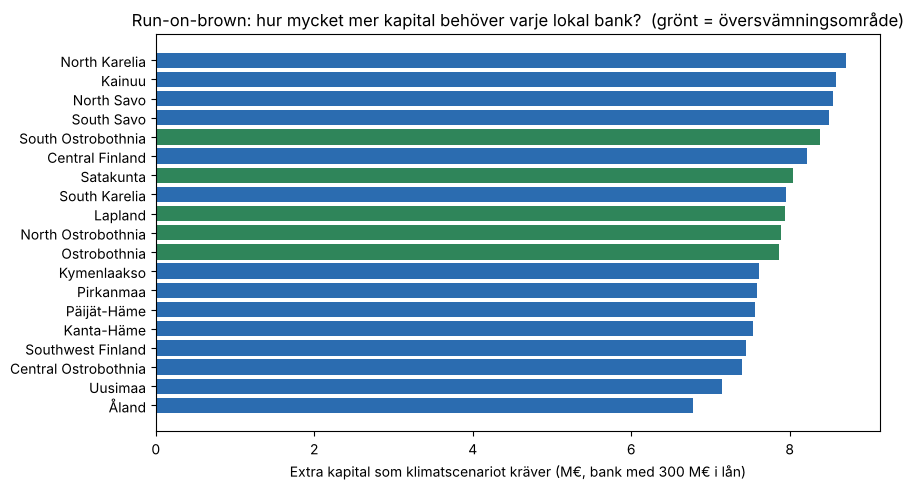

,Landskap,Andel jordbruk %,Översvämning,EL idag (M€),EL klimat (M€),Kapital idag (M€),Kapital klimat (M€),Extra kapital pga klimat (M€)
10,North Karelia,70.3800,False,3.6900,5.6800,44.7600,53.4600,8.7000
16,Kainuu,71.3600,False,5.0400,7.7600,50.4700,59.0600,8.5900
9,North Savo,68.3500,False,3.6500,5.6200,43.9300,52.4700,8.5400
8,South Savo,71.3000,False,3.3500,5.1700,42.5800,51.0800,8.5000
12,South Ostrobothnia,65.2400,True,3.9800,6.1300,51.6500,60.0400,8.3900
11,Central Finland,59.4100,False,2.7700,4.2700,38.3400,46.5500,8.2100
2,Satakunta,52.7200,True,3.1300,4.8100,44.6500,52.6900,8.0400
7,South Karelia,62.0300,False,2.3100,3.5600,35.4200,43.3700,7.9600
17,Lapland,53.3200,True,3.3400,5.1500,45.6500,53.5900,7.9400
15,North Ostrobothnia,58.3100,True,4.2400,6.5200,50.7200,58.6100,7.8900


In [6]:
rows = []
for reg in m.regions:
    t, s = m.bank_metrics(reg, "Today"), m.bank_metrics(reg, m.p["main_scenario"])
    rows.append({"Landskap": reg.split(" ", 1)[1], "Andel jordbruk %": m.shares.loc[reg, "Agriculture"] * 100,
                 "Översvämning": reg in m.p["flood_regions"],
                 "EL idag (M€)": t["expected_loss_meur"], "EL klimat (M€)": s["expected_loss_meur"],
                 "Kapital idag (M€)": t["capital_meur"], "Kapital klimat (M€)": s["capital_meur"]})
landskap = pd.DataFrame(rows)
landskap["Extra kapital pga klimat (M€)"] = landskap["Kapital klimat (M€)"] - landskap["Kapital idag (M€)"]
landskap = landskap.sort_values("Extra kapital pga klimat (M€)", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2f855a" if f else "#2b6cb0" for f in landskap["Översvämning"]]
ax.barh(landskap["Landskap"], landskap["Extra kapital pga klimat (M€)"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Extra kapital som klimatscenariot kräver (M€, bank med 300 M€ i lån)")
ax.set_title("Run-on-brown: hur mycket mer kapital behöver varje lokal bank?  (grönt = översvämningsområde)")
plt.tight_layout(); plt.show()
landskap.round(2)

## 5. Prissätt ett lån

Exempel: jordbruksföretag, 500 000 €, soliditet 30 %, nettoskuld/EBITDA 4.

In [7]:
ex = dict(sector="Agriculture", amount_eur=500_000, equity_ratio=0.30, net_debt_ebitda=4.0)
rows = []
for reg in [LAND, STAD, "MK16 Central Ostrobothnia", "MK06 Pirkanmaa"]:
    r = m.price_loan(reg, **ex)
    rows.append({"Landskap": reg.split(" ", 1)[1], "Euribor %": r["euribor"] * 100, "Marginal %": r["bank_margin"] * 100,
                 "Egen klimatrisk %": r["climate_addon_own_risk"] * 100,
                 "Koncentration %": r["climate_addon_concentration"] * 100,
                 "Klimatpåslag %": r["climate_addon"] * 100, "Total ränta %": r["total_rate"] * 100})
pd.DataFrame(rows).round(2)

,Landskap,Euribor %,Marginal %,Egen klimatrisk %,Koncentration %,Klimatpåslag %,Total ränta %
0,Ostrobothnia,2.2000,2.0000,1.1500,0.3200,1.4700,5.6700
1,Uusimaa,2.2000,2.0000,0.8000,0.3200,1.1200,5.3200
2,Central Ostrobothnia,2.2000,2.0000,1.4500,0.3000,1.7500,5.9500
3,Pirkanmaa,2.2000,2.0000,0.7100,0.3300,1.0400,5.2400


In [8]:
# Samma lån, olika bransch och företagets nyckeltal
rows = []
for sec in SECTORS:
    for label, kw in [("starkt", dict(equity_ratio=0.5, net_debt_ebitda=2)),
                      ("nöjaktigt", dict(equity_ratio=0.3, net_debt_ebitda=4)),
                      ("svagt", dict(equity_ratio=0.1, net_debt_ebitda=6)),
                      ("betalningsanmärkning", dict(payment_default=True))]:
        r = m.price_loan(LAND, sec, 500_000, **kw)
        rows.append({"Bransch": sec, "Företag": label, "Klimatpåslag %": r["climate_addon"] * 100,
                     "Total ränta %": r["total_rate"] * 100})
pd.DataFrame(rows).pivot(index="Bransch", columns="Företag", values="Klimatpåslag %").round(2)

Företag,betalningsanmärkning,nöjaktigt,starkt,svagt
Bransch,,,,
Agriculture,4.4400,1.4700,0.9200,2.4800
Construction,0.9700,0.3900,0.2400,0.6100
Trade,0.7800,0.2600,0.1500,0.4500


**Lånebeloppet** påverkar påslaget lite: så länge lånet är litet jämfört med bankens 300 M€ blir påslaget i procent nästan detsamma. Det stämmer med hur banker resonerar. Det är koncentrationen till *branschen* som kostar, inte storleken på ett enskilt lån.

In [9]:
pd.DataFrame([{"Lånebelopp €": a, "Klimatpåslag %": m.price_loan(LAND, "Agriculture", a)["climate_addon"] * 100}
              for a in [100_000, 500_000, 2_000_000, 10_000_000]]).round(3)

,Lånebelopp €,Klimatpåslag %
0,100000,1.4720
1,500000,1.4700
2,2000000,1.4670
3,10000000,1.4440


## 6. Ändra ett antagande

Tänk om jordbrukets PD är 5 % i stället för 3,5 %? Skicka in en ändring (`overrides`), så räknas allt om. Samma sak gör reglagen i appen.

In [10]:
m_hog = Model(load_params(overrides={"pd_agriculture_national": 0.05}))
for namn, modell in [("Standard (3,5 %)", m), ("Jordbruks-PD 5 %", m_hog)]:
    r = modell.price_loan(LAND, "Agriculture", 500_000)
    print(f"{namn:18s} klimatpåslag {r['climate_addon']*100:.2f} %   total ränta {r['total_rate']*100:.2f} %")

Standard (3,5 %)   klimatpåslag 1.47 %   total ränta 5.67 %
Jordbruks-PD 5 %   klimatpåslag 1.91 %   total ränta 6.11 %


## 7. Kvantmodellen

Eftersom varje bransch har många små lån bestäms bankens förlust helt av ekonomi- och klimatläget. Kretsen behöver därför bara:
- 4 qubits för ekonomin och 4 för klimatet (16 × 16 = 256 lägen)
- 1 qubit som markerar "stor förlust" (minst 10 % av lånestocken), eller som kodar in förlusten för att räkna förväntad förlust

QAE (Iterative Amplitude Estimation) uppskattar sedan sannolikheten. Facit är samma 256 lägen räknade klassiskt. Det fina rutnätet (241 × 241) visar hur mycket upplösningen påverkar.

In [11]:
%run kvant_v5.py

Done: Rural bank (Ostrobothnia) - Today


Done: Rural bank (Ostrobothnia) - Run-on-brown


Done: City bank (Uusimaa) - Today


Done: City bank (Uusimaa) - Run-on-brown

                                                                   0                          1                    2                    3
Bank                                       Rural bank (Ostrobothnia)  Rural bank (Ostrobothnia)  City bank (Uusimaa)  City bank (Uusimaa)
Scenario                                                       Today               Run-on-brown                Today         Run-on-brown
Qubits                                                             9                          9                    9                    9
Large loss threshold (MEUR)                                  30.0000                    30.0000              30.0000              30.0000
P(large loss) exact %                                         0.7260                     3.0460               0.0420               0.1520
P(large loss) QAE %                                           0.7250                     2.9660               0.0420              

## 8. Riktig kvanthårdvara (IQM / IBM)

Full QAE kräver tusentals 2-qubitgrindar, vilket dagens maskiner inte klarar utan att bruset tar över. På hårdvaran kör vi därför osäkerhetsmodellen: 2 + 2 qubits för ekonomi och klimat (16 lägen) och 1 qubit där sannolikheten för 1 är förväntad förlust delat med maxförlust. Det blir cirka 20 2-qubitgrindar.

Utan inloggning körs en brusfri simulator och IQM:s brusiga modell av deras 20-qubitmaskin Apollo. Med inloggning: `run_on("iqm", url=..., token=...)` eller `run_on("ibm", token=..., instance=...)`.

In [12]:
%run kvant_hardware.py

 Backend                      Bank     Scenario  Expected loss exact (MEUR)  Measured, raw (MEUR)  Measured, readout-corrected (MEUR)  Two-qubit gates
   ideal Rural bank (Ostrobothnia)        Today                      4.2600                4.3000                              4.3000               18
   ideal Rural bank (Ostrobothnia) Run-on-brown                      6.6000                6.0700                              6.0700               18
   ideal       City bank (Uusimaa)        Today                      2.1100                1.8900                              1.8900               18
   ideal       City bank (Uusimaa) Run-on-brown                      3.2600                3.4200                              3.4200               18
iqm-fake Rural bank (Ostrobothnia)        Today                      4.2600               12.5200                             11.5100               24
iqm-fake Rural bank (Ostrobothnia) Run-on-brown                      6.6000               15.4

**Tolkning:** Den brusfria simulatorn träffar facit. På IQM:s brusiga modell blåser bruset upp förlusten ungefär 2–3 gånger, men ordningen håller: landsbygdsbanken ligger högre än stadsbanken, och klimatscenariot högre än idag.
Det är NISQ-läget i ett nötskal. Vår klimatmodell går redan att köra på en kvantdator, men exakta svar och kvantfördelen kräver felkorrigerade kvantdatorer.